In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron, SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Carregando os dados
iris = load_iris()
X = iris.data  # As 4 características
y = iris.target # As 3 classes (0, 1, 2)

# Padronização (Requisito obrigatório do projeto)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dados carregados e padronizados com sucesso!")

Dados carregados e padronizados com sucesso!


In [2]:
def treinar_modelo(tipo, X_dados, y_dados):
    acuracias = []
    matrizes = []
    
    for i in range(10): # Mínimo de 10 execuções independentes
        # Mudamos o random_state a cada loop para garantir independência
        X_train, X_test, y_train, y_test = train_test_split(
            X_dados, y_dados, test_size=0.3, random_state=i, stratify=y_dados
        )
        
        if tipo == 'Perceptron':
            modelo = Perceptron(eta0=0.1, random_state=i)
        elif tipo == 'ADALINE':
            # SGD com squared_error simula o ADALINE (gradiente descendente)
            modelo = SGDClassifier(loss='squared_error', learning_rate='constant', eta0=0.01, random_state=i)
        elif tipo == 'MLP':
            modelo = MLPClassifier(hidden_layer_sizes=(10, 5), max_iter=1000, random_state=i)
            
        modelo.fit(X_train, y_train)
        pred = modelo.predict(X_test)
        
        acuracias.append(accuracy_score(y_test, pred))
        matrizes.append(confusion_matrix(y_test, pred))
        
    print(f"\n--- Resultados {tipo} ---")
    print(f"Acurácia Média: {np.mean(acuracias):.4f}")
    print(f"Desvio Padrão: {np.std(acuracias):.4f}")
    
    # Matriz de Confusão Média (arredondada para facilitar leitura)
    matriz_media = np.mean(matrizes, axis=0).astype(int)
    return matriz_media

# Executando para os 3 modelos
matriz_p = treinar_modelo('Perceptron', X_scaled, y)
matriz_a = treinar_modelo('ADALINE', X_scaled, y)
matriz_m = treinar_modelo('MLP', X_scaled, y)


--- Resultados Perceptron ---
Acurácia Média: 0.8689
Desvio Padrão: 0.0956

--- Resultados ADALINE ---
Acurácia Média: 0.8289
Desvio Padrão: 0.0597


C:\Users\maril\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



--- Resultados MLP ---
Acurácia Média: 0.9444
Desvio Padrão: 0.0425


C:\Users\maril\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


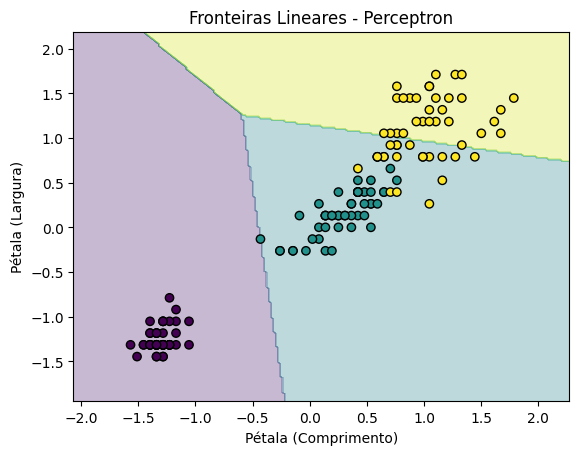

C:\Users\maril\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


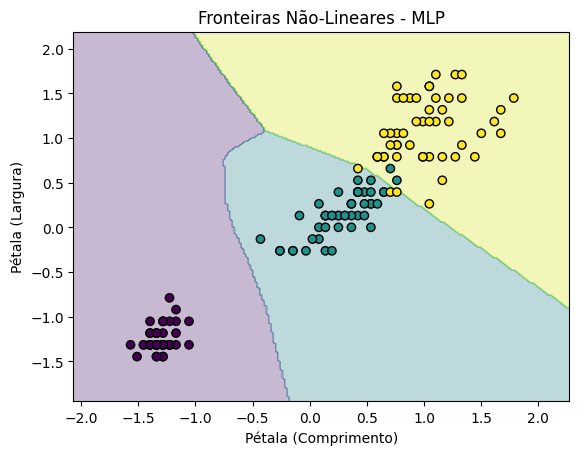

In [3]:
def plot_fronteiras(modelo, titulo):
    # Usando apenas 2 atributos para visualização 2D
    X_vis = X_scaled[:, [2, 3]] 
    modelo.fit(X_vis, y)
    
    x_min, x_max = X_vis[:, 0].min() - 0.5, X_vis[:, 0].max() + 0.5
    y_min, y_max = X_vis[:, 1].min() - 0.5, X_vis[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = modelo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolors='k')
    plt.title(titulo)
    plt.xlabel('Pétala (Comprimento)')
    plt.ylabel('Pétala (Largura)')
    plt.show()

# Gerar os gráficos
plot_fronteiras(Perceptron(), "Fronteiras Lineares - Perceptron")
plot_fronteiras(MLPClassifier(hidden_layer_sizes=(10, 8)), "Fronteiras Não-Lineares - MLP")

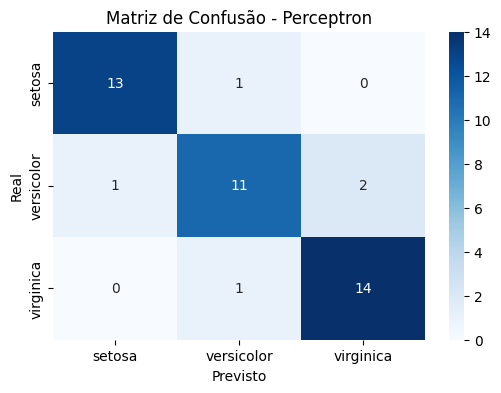

Matriz do Perceptron salva em: ../experimentos/matriz_perceptron.png


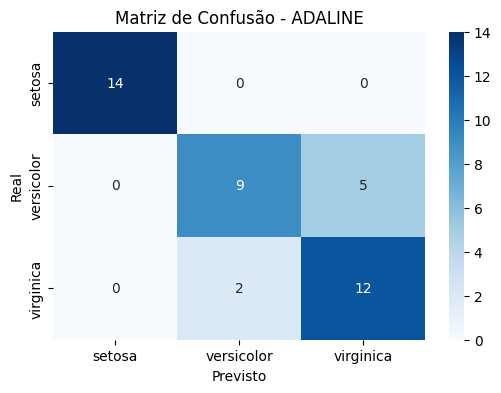

Matriz do ADALINE salva em: ../experimentos/matriz_adaline.png


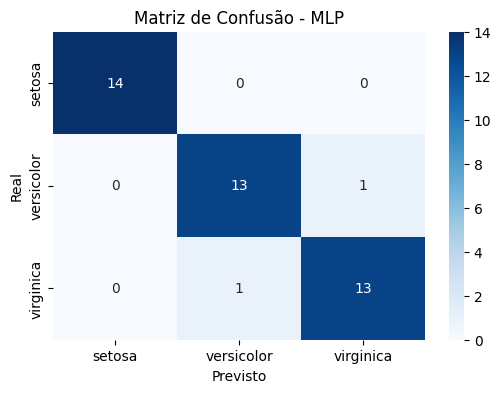

Matriz do MLP salva em: ../experimentos/matriz_mlp.png


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

def salvar_matriz_confusao(matriz, modelo_nome):
    plt.figure(figsize=(6, 4))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', 
                xticklabels=iris.target_names, 
                yticklabels=iris.target_names)
    plt.title(f'Matriz de Confusão - {modelo_nome}')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    
    # Salva na pasta de experimentos
    caminho = f"../experimentos/matriz_{modelo_nome.lower()}.png"
    plt.savefig(caminho)
    plt.show()
    print(f"Matriz do {modelo_nome} salva em: {caminho}")

# Chamando a função para os resultados que você já tinha:
salvar_matriz_confusao(matriz_p, "Perceptron")
salvar_matriz_confusao(matriz_a, "ADALINE")
salvar_matriz_confusao(matriz_m, "MLP")